# 01 - Churn Modelling EDA

**Amac:** Churn_Modelling veri setinin kalitesini ve hedef degiskenle iliskilerini incelemek.
**Girdi:** data/raw/Churn_Modelling.csv
**Cikti:** reports/figures/*.png, reports/data_quality.md, data/processed/churn_masked.parquet


In [1]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
raw_path = Path("../data/raw/Churn_Modelling.csv")
df = pd.read_csv(raw_path)
df.shape


(10000, 14)

## 1. PII Maskeleme
`Surname` (ad) hash'lenir, `CustomerId` ve `RowNumber` modelleme icin disi ozellikler.


In [3]:
def _hash(x: str) -> str:
    return hashlib.sha256(str(x).encode()).hexdigest()[:10]

df["Surname"] = df["Surname"].map(_hash)
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,fdcd57e82f,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,21f5358c1f,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,b839933c7b,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,cb1edc7273,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,483d4bce16,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Sema ve Tip Dogrulamasi


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.3 MB


In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,9f54259010,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


## 3. Veri Kalitesi: Eksik, Duplicate, Kardinalite


In [6]:
missing = df.isna().mean().mul(100).round(2).rename("missing_pct")
dup_rows = int(df.duplicated().sum())
dup_cust = int(df["CustomerId"].duplicated().sum())
nunique = df.nunique().rename("nunique")
quality = pd.concat([missing, nunique], axis=1)
print(f"duplicate rows: {dup_rows} | duplicate CustomerId: {dup_cust}")
quality


duplicate rows: 0 | duplicate CustomerId: 0


,missing_pct,nunique
RowNumber,0.0,10000
CustomerId,0.0,10000
Surname,0.0,2932
CreditScore,0.0,460
Geography,0.0,3
Gender,0.0,2
Age,0.0,70
Tenure,0.0,11
Balance,0.0,6382
NumOfProducts,0.0,4


## 4. Hedef Degisken Dagilimi (Exited)


Exited
0    0.7963
1    0.2037
Name: ratio, dtype: float64


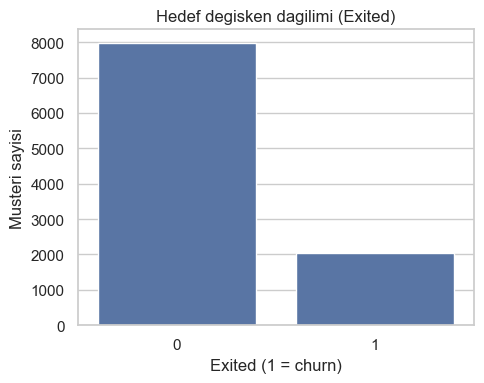

In [7]:
target_dist = df["Exited"].value_counts(normalize=True).rename("ratio")
print(target_dist.round(4))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Exited", data=df, ax=ax)
ax.set_title("Hedef degisken dagilimi (Exited)")
ax.set_xlabel("Exited (1 = churn)")
ax.set_ylabel("Musteri sayisi")
fig.tight_layout()
fig.savefig(FIG_DIR / "target_distribution.png", dpi=120)
plt.show()


## 5. Sayisal Degiskenler: Histogram + Boxplot


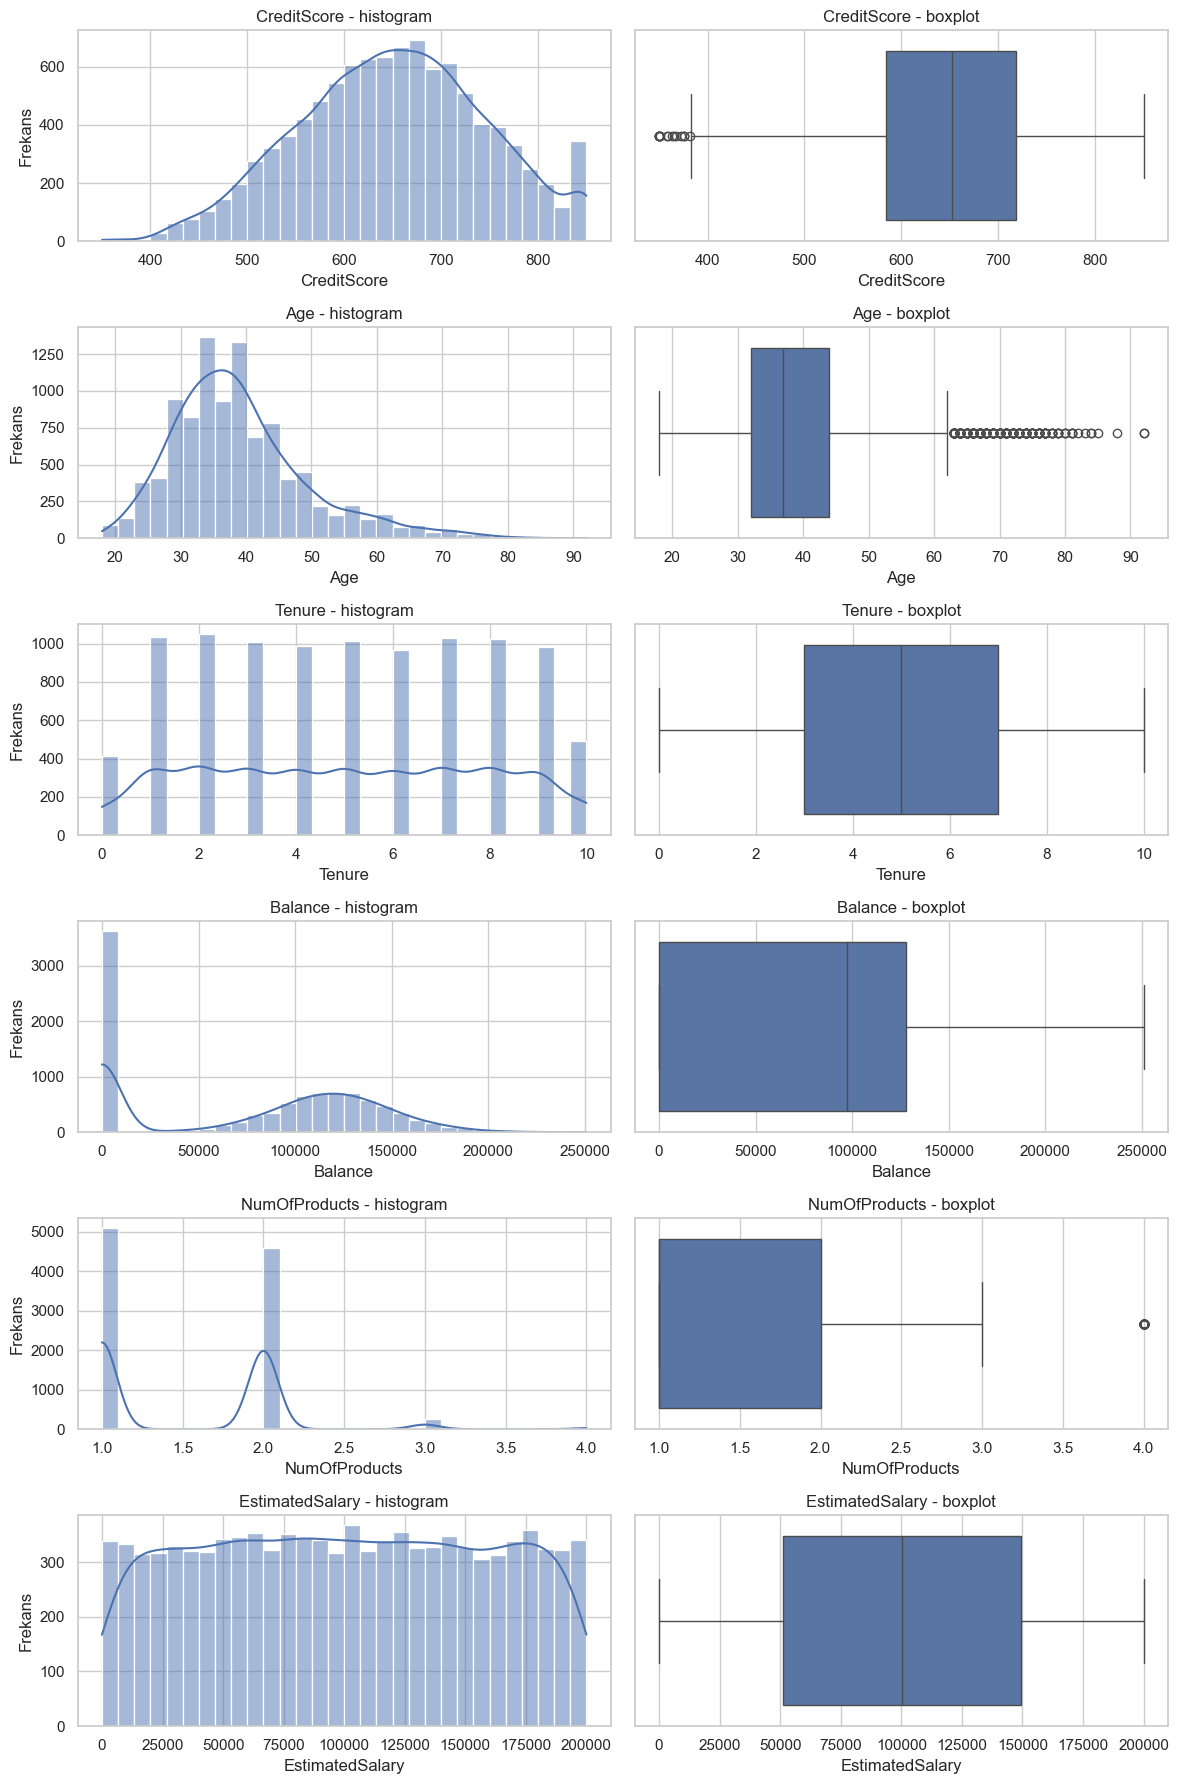

In [8]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3 * len(num_cols)))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} - histogram")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Frekans")
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} - boxplot")
    axes[i, 1].set_xlabel(col)
fig.tight_layout()
fig.savefig(FIG_DIR / "numeric_distributions.png", dpi=120)
plt.show()


## 6. Kategorik Degiskenler


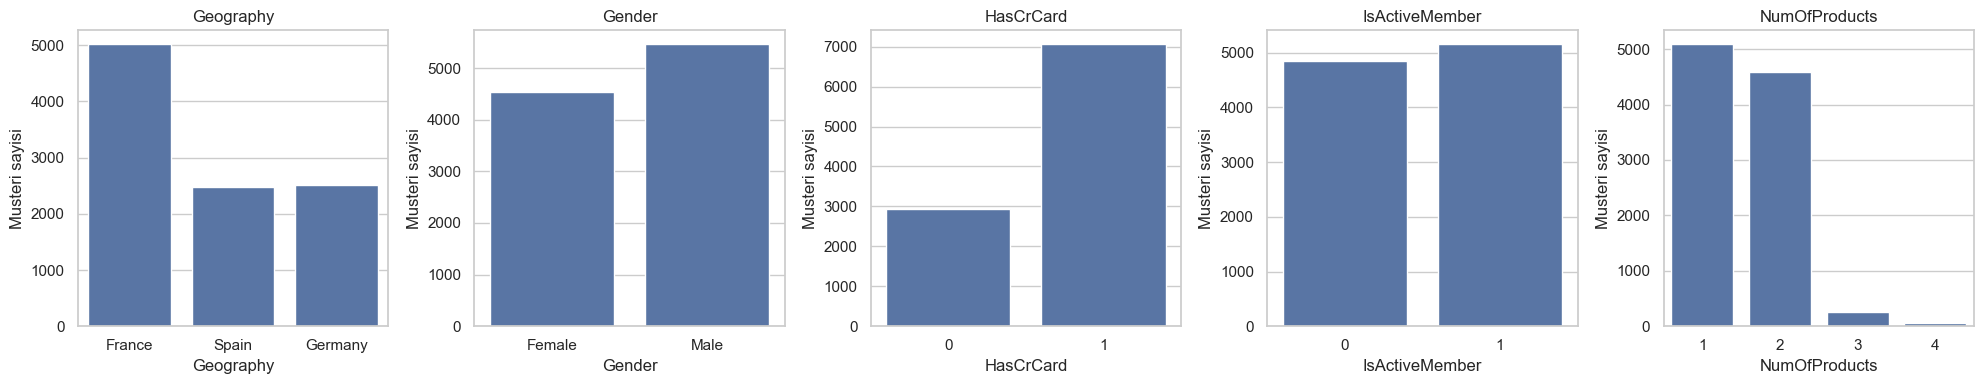

In [9]:
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "NumOfProducts"]
fig, axes = plt.subplots(1, len(cat_cols), figsize=(4 * len(cat_cols), 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Musteri sayisi")
fig.tight_layout()
fig.savefig(FIG_DIR / "categorical_counts.png", dpi=120)
plt.show()


## 7. Segment Bazinda Churn Orani


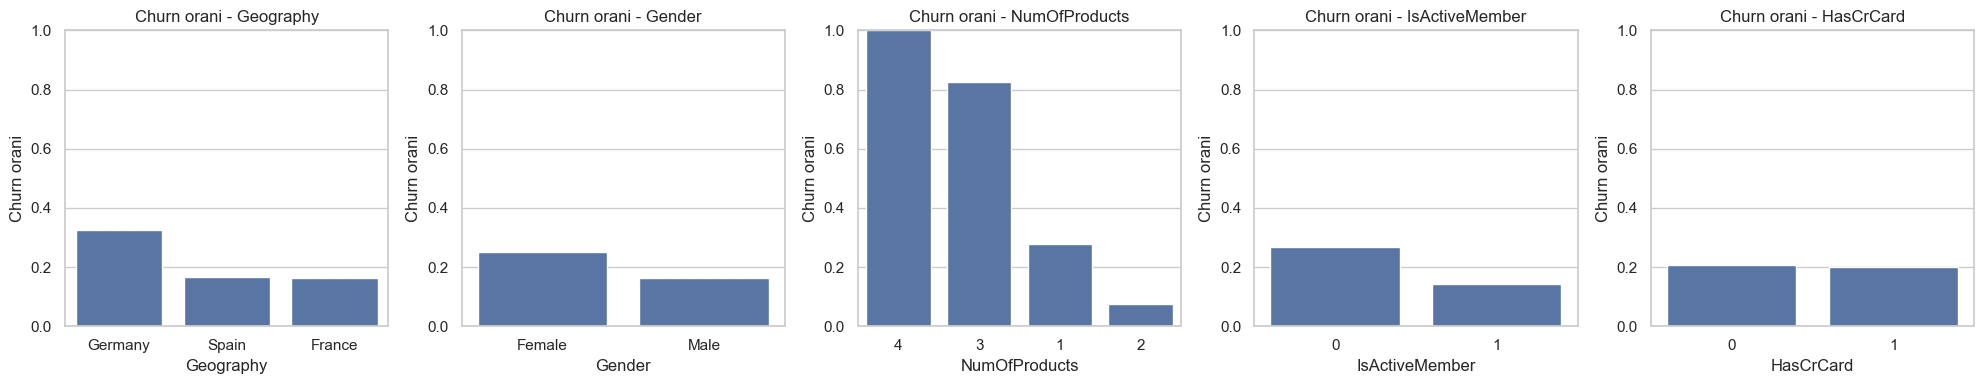

In [10]:
segments = ["Geography", "Gender", "NumOfProducts", "IsActiveMember", "HasCrCard"]
fig, axes = plt.subplots(1, len(segments), figsize=(4 * len(segments), 4))
for ax, col in zip(axes, segments):
    rates = df.groupby(col)["Exited"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax)
    ax.set_title(f"Churn orani - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Churn orani")
    ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(FIG_DIR / "churn_rate_by_segment.png", dpi=120)
plt.show()


## 8. Korelasyon Isi Haritasi


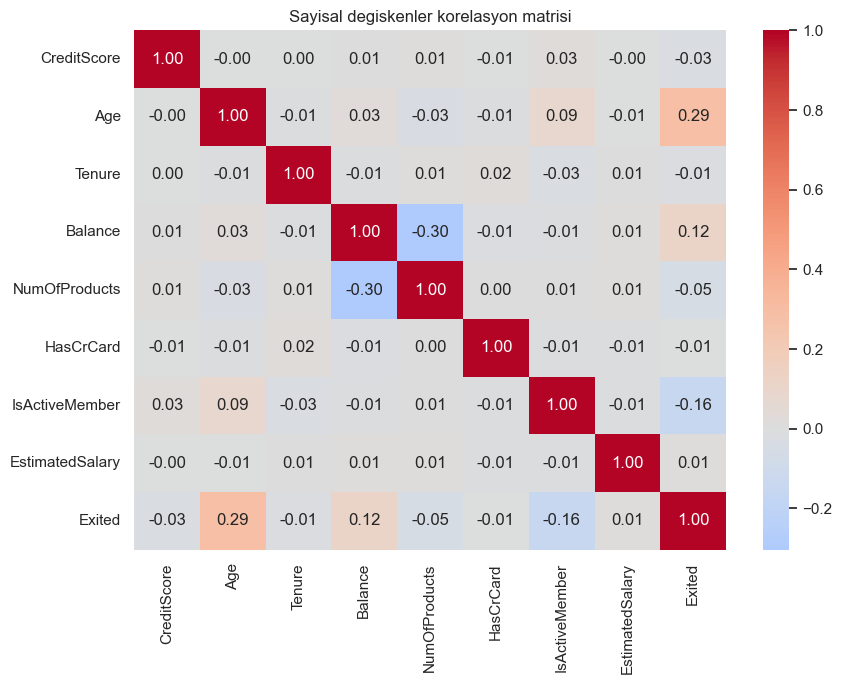

IsActiveMember    -0.156128
NumOfProducts     -0.047820
CreditScore       -0.027094
Tenure            -0.014001
HasCrCard         -0.007138
EstimatedSalary    0.012097
Balance            0.118533
Age                0.285323
Exited             1.000000
Name: Exited, dtype: float64

In [11]:
num_df = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).select_dtypes("number")
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Sayisal degiskenler korelasyon matrisi")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", dpi=120)
plt.show()

corr["Exited"].sort_values()


## 9. Outlier Ozeti (IQR)


In [12]:
def iqr_outliers(s: pd.Series) -> int:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum())

outlier_summary = pd.DataFrame(
    {col: [iqr_outliers(df[col]), iqr_outliers(df[col]) / len(df)] for col in num_cols},
    index=["count", "ratio"],
).T.round(4)
outlier_summary


,count,ratio
CreditScore,15.0,0.0015
Age,359.0,0.0359
Tenure,0.0,0.0000
Balance,0.0,0.0000
NumOfProducts,60.0,0.0060
EstimatedSalary,0.0,0.0000


## 10. Islenmis (maskelenmis) Snapshot Kaydet


In [13]:
out_path = Path("../data/processed/churn_masked.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(out_path, index=False)
out_path


WindowsPath('../data/processed/churn_masked.parquet')